First 5 records:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no



Dataset Shape: (4521, 17)

Model Accuracy: 89.17%

Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.97      0.94       801
         Yes       0.55      0.30      0.39       104

    accuracy                           0.89       905
   macro avg       0.73      0.63      0.66       905
weighted avg       0.87      0.89      0.88       905


Confusion Matrix:
[[776  25]
 [ 73  31]]


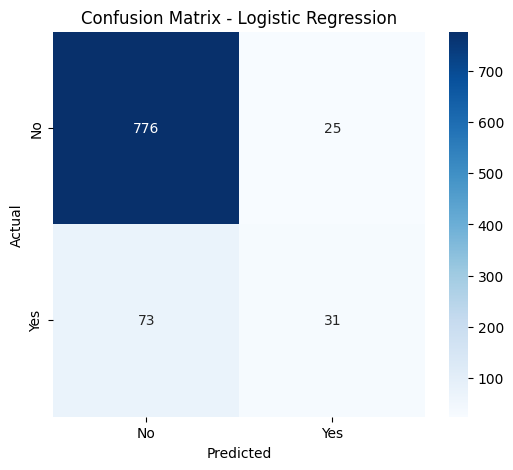


Conclusion:
Logistic Regression was successfully implemented on
the Bank Marketing dataset.
The model achieved an accuracy of 89.17%.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
!wget -q $url -O bank.zip
!unzip -o -q bank.zip

df = pd.read_csv("bank.csv", sep=";")


print("First 5 records:")
display(df.head())

print("\nDataset Shape:", df.shape)


X = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})


X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", f"{accuracy * 100:.2f}%")


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nConclusion:")
print("Logistic Regression was successfully implemented on")
print("the Bank Marketing dataset.")
print(f"The model achieved an accuracy of {accuracy * 100:.2f}%.")